## Construction of the trajectories
We compare MovingPandas and MobilityPandas (which uses PyMEOS) libraries.

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Point

from geopandas import GeoDataFrame
import zipfile

import sys
sys.path.append("..")
import movingpandas as mpd

import warnings
import numpy as np
warnings.simplefilter("ignore")
from pyproj import Transformer

import pymeos
from pymeos import TGeomPointSeq
pymeos.pymeos_initialize()

We use AIS data.

In [12]:
zip_path = 'data/aisdk-2025-07-11.zip'
csv_filename = 'aisdk-2025-07-11.csv'

sizes = {'small': 100000, 'medium': 1000000, 'large': 5000000}
chosen_size = 'small'

In [13]:
def extraction():
    global df
    with zipfile.ZipFile(zip_path) as archive:        
        with archive.open(csv_filename) as file:
            df = pd.read_csv(file, usecols=['# Timestamp', 'MMSI', 'Latitude', 'Longitude'], nrows=sizes[chosen_size])

    df.rename(columns={'# Timestamp': 't', 'MMSI': 'mmsi', 'Latitude': 'lat', 'Longitude': 'lon'}, inplace=True)
    df = df[df['lat'] <= 90] # default latitude = 91°
    df = df.sort_values(['mmsi', 't'])
    df = df.drop_duplicates(subset=['mmsi', 't'], keep='last')

    transformer = Transformer.from_crs("EPSG:4326", "EPSG:25832", always_xy=True)

    df[['x', 'y']] = df.apply(
        lambda row: pd.Series(transformer.transform(row['lon'], row['lat'])),
        axis=1
    )

    global nb_points
    nb_points = df.shape[0]

# extraction()

## MovingPandas (without PyMEOS)

In [14]:
def construction_mpd():
    df1 = df.copy()
    df1['geometry'] = [Point(lon, lat) for lon, lat in zip(df1['x'], df1['y'])]
    gdf = GeoDataFrame(df1, geometry='geometry')
    gdf.set_crs(epsg=25832, inplace=True)
    gdf['t'] = pd.to_datetime(gdf['t'])
    gdf = gdf.drop(columns=['lat', 'lon'])

    global trajectories_without
    trajectories_without = mpd.TrajectoryCollection(gdf, traj_id_col='mmsi', t='t')

## MobilityPandas (with PyMEOS)
We use `from_arrays` method.

In [15]:
def construction_pymeos():

    df3 = df.copy()
    df3['t'] = pd.to_datetime(df3['t'])

    global trajectories_with
    tr = (df3.groupby('mmsi')
        .apply(lambda traj: TGeomPointSeq.from_arrays(
            t = traj['t'].dt.strftime('%Y-%m-%d %H:%M:%S').values,
            x = traj['x'].values, 
            y = traj['y'].values,
            srid = 25832,
            upper_inc=True,
        ))
        .rename('trajectory')
    ).to_frame()

    trajectories_with = tr['trajectory'].apply(
        lambda seq: TGeomPointSeq.from_instants(seq.instants(), upper_inc=True)
    ).to_frame(name='trajectory')


## Measures

In [16]:
import time
from memory_profiler import memory_usage
results = {}

def mem_and_cpu_time(f, n=6):

    mem_usage = memory_usage((f), interval=0.01)
    mem_used = max(mem_usage) - min(mem_usage)

    times = []
    for _ in range(n):
        start = time.process_time()
        f()
        end = time.process_time()

        cpu_time = end - start
        times.append(cpu_time)

    times.pop(times.index(max(times)))
    times.pop(times.index(min(times)))
    mean_t = np.mean(times)
    std_t = np.std(times)
    results[f.__name__] = (mean_t, mem_used)
    # results[f.__name__] = (mean_t, 0)  # if you don't want to calculate memory usage


    print(f"Function {f.__name__}:")
    print(f"CPU time over {n} runs: {mean_t:.6f} sec ± {std_t:.6f} sec")
    print(f"Memory usage : {mem_used:.2f} MiB\n")


mem_and_cpu_time(extraction)
mem_and_cpu_time(construction_mpd)
mem_and_cpu_time(construction_pymeos)

Function extraction:
CPU time over 6 runs: 3.325979 sec ± 0.188121 sec
Memory usage : 84.23 MiB

Function construction_mpd:
CPU time over 6 runs: 3.386915 sec ± 0.277345 sec
Memory usage : 3.12 MiB

Function construction_pymeos:
CPU time over 6 runs: 0.877098 sec ± 0.067622 sec
Memory usage : 0.00 MiB



# Performance measures

## Reduction

In [17]:
kept_points_without = 0
for traj in trajectories_without.trajectories :
    kept_points_without += traj.size()

kept_points_with = 0
for traj in trajectories_with['trajectory'] :
    kept_points_with += traj.num_instants()

print("Percentage of points kept : (with mpd, with pymeos)")
print(np.round(kept_points_without*100/nb_points, 2), '%,  ',
      np.round(kept_points_with*100/nb_points, 2), '%,  ')

Percentage of points kept : (with mpd, with pymeos)
96.61 %,   92.14 %,  


## Time and memory

### Construction of the trajectories

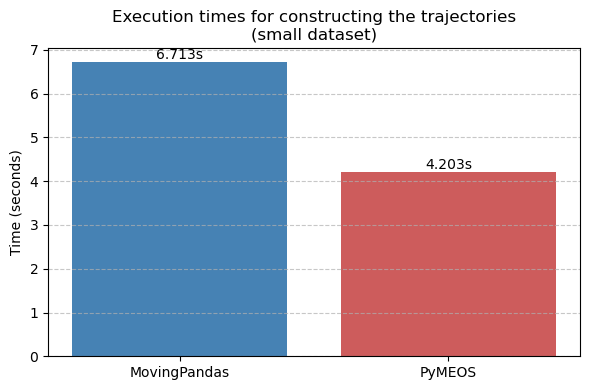

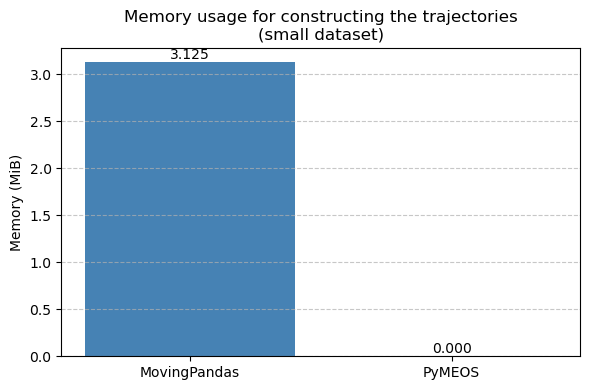

In [19]:
timesCo = [results['extraction'][0] + results['construction_mpd'][0], results['extraction'][0]+ results['construction_pymeos'][0]]
memCo = [results['construction_mpd'][1], results['construction_pymeos'][1]]
libs = ['MovingPandas', 'PyMEOS']


plt.figure(figsize=(6, 4))
bars = plt.bar(libs, timesCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}s", ha='center', va='bottom')

plt.title(f"Execution times for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Time (seconds)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
bars = plt.bar(libs, memCo, color=['steelblue', 'indianred'])
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f"{yval:.3f}", ha='center', va='bottom')

plt.title(f"Memory usage for constructing the trajectories\n({chosen_size} dataset)")
plt.ylabel("Memory (MiB)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Let see

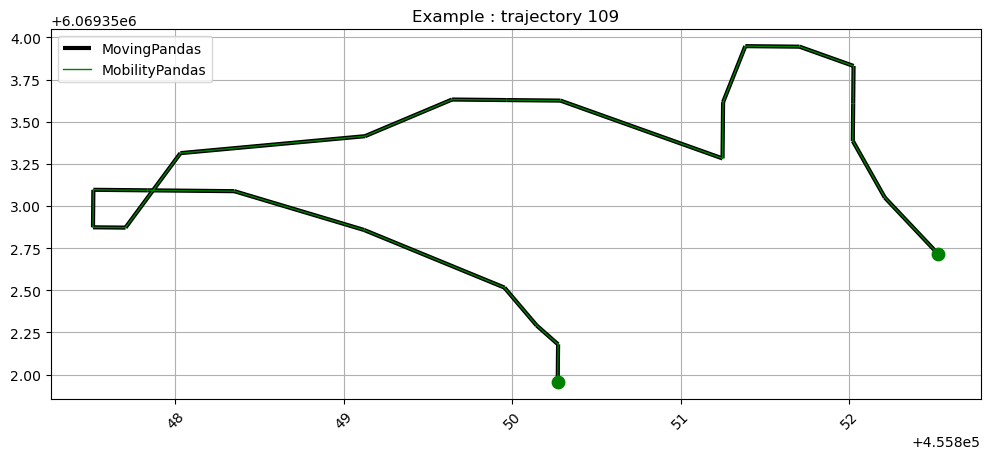

In [ ]:
# Plot one trajectory

n=109
m = [traj.id for traj in trajectories_without][n] # the corresponding MMSI

fig, ax = plt.subplots(figsize=(12, 8))
trajectories_without.trajectories[n].plot(color='black', label='MovingPandas', linewidth=3, ax=ax)
trajectories_with['trajectory'][m].plot(color='green', label='MobilityPandas', linewidth=1)

plt.title("Example : trajectory {0}".format(n))
plt.legend()
plt.show()